<a href="https://colab.research.google.com/github/OleSpooky/README/blob/main/oasisengine_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This cell was a duplicate and has been cleared. The active SovereignLattice class is in cell x_4IzekmG9Bp.

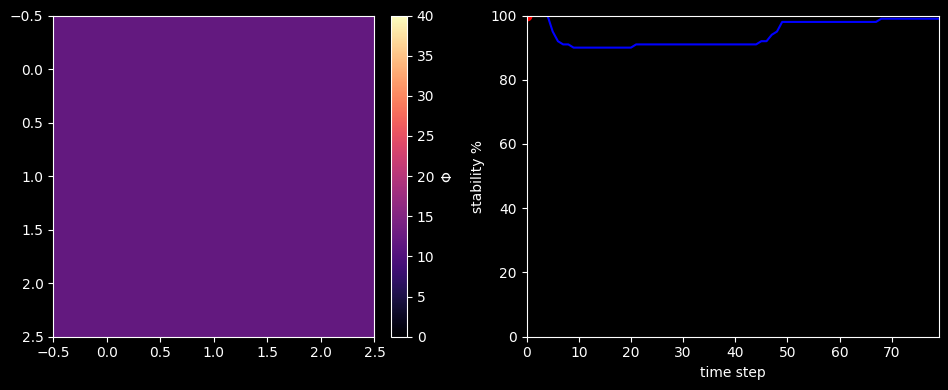

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

class SovereignLattice:
    def __init__(
        self,
        grid_size=3,
        baseline_phi=12.0,
        internal_coupling=3.0,
        hardening_alpha=0.5,
        neighbor_coupling_factor=0.20,
        decay_rate=0.05,
        min_phi=0.0,
        max_phi=40.0,
        mode="defense",
    ):
        self.n = grid_size
        self.baseline_phi = baseline_phi
        self.c = internal_coupling
        self.alpha = hardening_alpha
        self.k = neighbor_coupling_factor
        self.decay_rate = decay_rate
        self.min_phi = min_phi
        self.max_phi = max_phi
        self.mode = mode

        self.phi = np.full((self.n, self.n), baseline_phi, dtype=float)
        self.tap_count = np.zeros((self.n, self.n), dtype=int)
        self.total_breaches = 0

    def set_mode(self, mode: str):
        assert mode in ("defense", "entropy")
        self.mode = mode

    def _neighbor_coupling(self):
        support = np.zeros_like(self.phi)
        k = self.k
        support[1:, :] += self.phi[:-1, :] * k
        support[:-1, :] += self.phi[1:, :] * k
        support[:, 1:] += self.phi[:, :-1] * k
        support[:, :-1] += self.phi[:, 1:] * k
        return support

    def tap(self, i, j, threat_energy: float):
        self.tap_count[i, j] += 1
        network_c = self._neighbor_coupling()[i, j]
        total_barrier = self.phi[i, j] + self.c + network_c
        leakage = max(0.0, threat_energy - total_barrier)

        if leakage > 0.0:
            self.total_breaches += 1
            if self.mode == "entropy":
                self.phi[i, j] = max(self.min_phi, self.phi[i, j] - self.alpha * leakage)
            else:
                self.phi[i, j] = min(self.max_phi, self.phi[i, j] + self.alpha * leakage)
        return leakage

    def step_decay(self):
        above = self.phi > self.baseline_phi
        below = self.phi < self.baseline_phi
        self.phi[above] -= self.decay_rate
        self.phi[below] += self.decay_rate
        # clamp and avoid overshoot
        self.phi = np.clip(self.phi, self.min_phi, self.max_phi)
        # snap small overshoots to baseline
        self.phi[np.isclose(self.phi, self.baseline_phi, atol=self.decay_rate/2)] = self.baseline_phi

    def stability_percent(self):
        max_dev = max(self.max_phi - self.baseline_phi, self.baseline_phi - self.min_phi)
        max_variance = (self.n * self.n) * max_dev
        if max_variance == 0:
            return 100
        total_variance = np.abs(self.phi - self.baseline_phi).sum()
        disturbance = total_variance / max_variance
        stability = (1.0 - disturbance) * 100.0
        return int(round(stability))

    def snapshot(self):
        return {
            "phi": self.phi.copy(),
            "tap_count": self.tap_count.copy(),
            "total_breaches": int(self.total_breaches),
            "stability_percent": self.stability_percent(),
        }

# Scenario + visualization helpers

def run_scenario(steps_def=40, steps_ent=40, threat_energy=50.0):
    lattice = SovereignLattice(grid_size=3)
    center = (1, 1)
    phi_history, stab_history = [], []

    lattice.set_mode("defense")
    for t in range(steps_def):
        if t in (5,6,7,8,9):
            lattice.tap(*center, threat_energy)
        lattice.step_decay()
        s = lattice.snapshot()
        phi_history.append(s["phi"])
        stab_history.append(s["stability_percent"])

    lattice.set_mode("entropy")
    for t in range(steps_ent):
        if t in (5,6,7,8,9):
            lattice.tap(*center, threat_energy)
        lattice.step_decay()
        s = lattice.snapshot()
        phi_history.append(s["phi"])
        stab_history.append(s["stability_percent"])

    return np.array(phi_history), np.array(stab_history)

def animate_lattice(phi_history, stab_history, save_mp4=False, mp4_name="sovereign_lattice.mp4"):
    T, n, _ = phi_history.shape
    fig, (ax_grid, ax_stab) = plt.subplots(1, 2, figsize=(10,4))
    im = ax_grid.imshow(phi_history[0], vmin=0, vmax=40, cmap="magma")
    fig.colorbar(im, ax=ax_grid, fraction=0.046, pad=0.04).set_label("Φ")
    t_vals = np.arange(T)
    ax_stab.plot(t_vals, stab_history, "-b", lw=1.5)
    point, = ax_stab.plot([0], [stab_history[0]], "or")
    ax_stab.set_ylim(0,100)
    ax_stab.set_xlim(0, T-1)
    ax_stab.set_xlabel("time step")
    ax_stab.set_ylabel("stability %")

    def update(frame):
        im.set_data(phi_history[frame])
        point.set_data([frame], [stab_history[frame]])
        ax_grid.set_xlabel(f"t = {frame}")
        return im, point

    ani = FuncAnimation(fig, update, frames=T, interval=150, blit=False)
    if save_mp4:
        ani.save(mp4_name, fps=10, dpi=150)
    plt.tight_layout()
    return ani, fig

# Run and show
if __name__ == "__main__":
    phi_hist, stab_hist = run_scenario(steps_def=40, steps_ent=40, threat_energy=50.0)
    ani, fig = animate_lattice(phi_hist, stab_hist, save_mp4=False)  # keep reference
    plt.show()

Running 4D Hyper-Bubble Simulation...


/usr/local/lib/python3.12/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


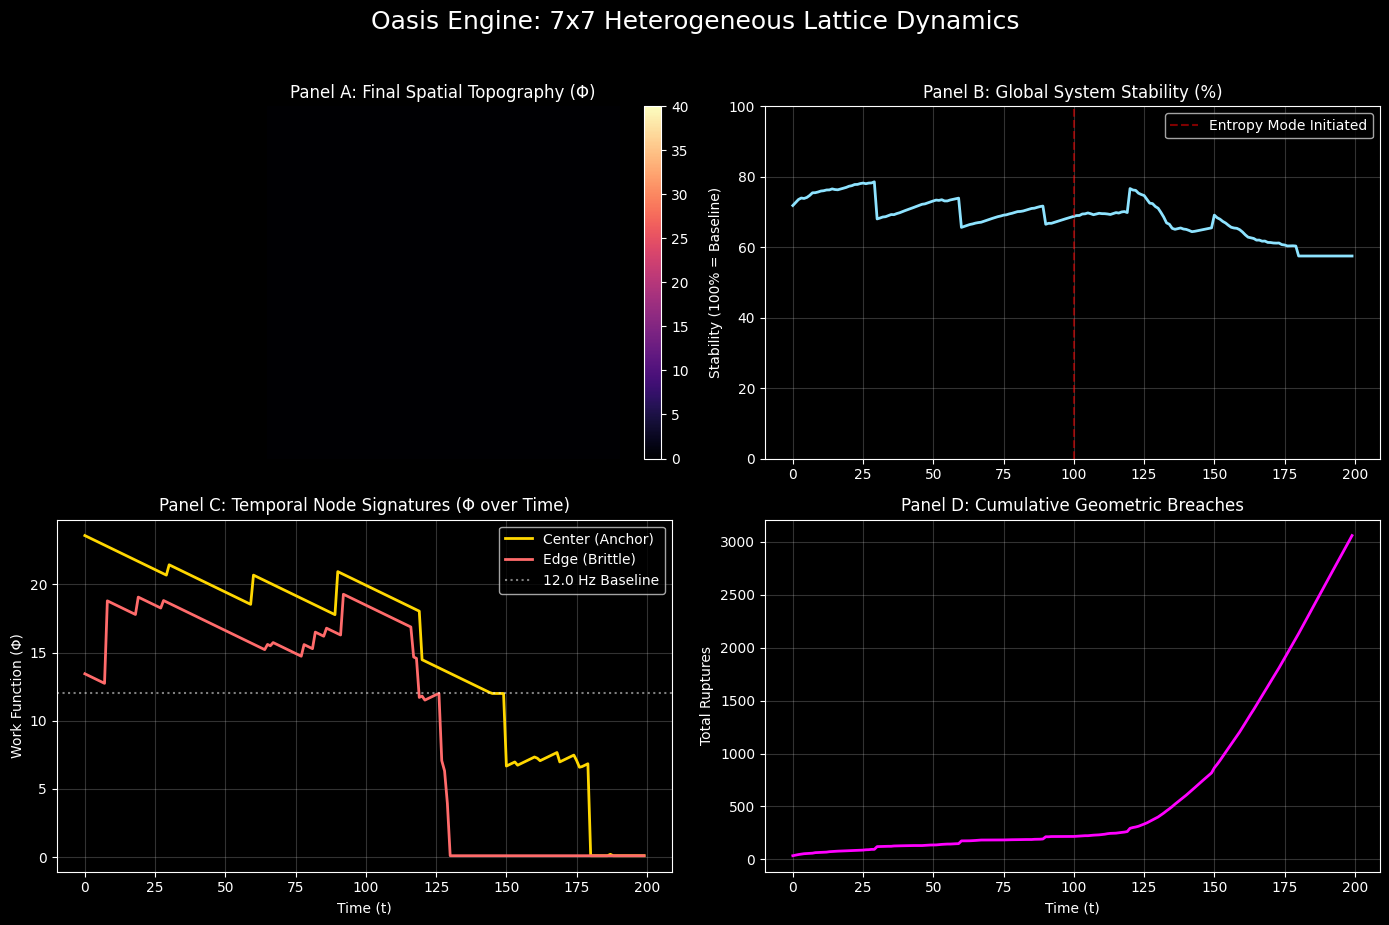

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# THE 7x7 HETEROGENEOUS OASIS KERNEL
# =====================================================================

GRID_SIZE = 7
BASELINE_PHI = 12.0
MAX_PHI = 40.0
MIN_PHI = 0.0

DECAY_RATE = 0.1
NEIGHBOR_COUPLING_FACTOR = 0.20

class SovereignNode:
    def __init__(self, name, initial_phi, coupling, alpha):
        self.name = name
        self.phi = initial_phi
        self.c = coupling
        self.alpha = alpha
        self.breach_count = 0

    def process_event(self, threat_energy, network_coupling, is_entropy_mode):
        total_barrier = self.phi + self.c + network_coupling
        leakage = np.maximum(0.0, threat_energy - total_barrier)

        if leakage > 0:
            self.breach_count += 1
            if is_entropy_mode:
                self.phi -= (self.alpha * leakage)
                self.phi = max(MIN_PHI, self.phi)
            else:
                self.phi += (self.alpha * leakage)
                self.phi = min(MAX_PHI, self.phi)
        return leakage

    def temporal_decay(self):
        if self.phi > BASELINE_PHI:
            self.phi -= DECAY_RATE
            self.phi = max(BASELINE_PHI, self.phi)
        elif self.phi < BASELINE_PHI:
            self.phi += DECAY_RATE
            self.phi = min(BASELINE_PHI, self.phi)

# =====================================================================
# INITIALIZING THE LATTICE
# =====================================================================

lattice = np.empty((GRID_SIZE, GRID_SIZE), dtype=object)

for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        # The Anchor (Center)
        if r == 3 and c == 3:
            lattice[r][c] = SovereignNode("Anchor", initial_phi=20.0, coupling=8.0, alpha=0.2)
        # The Brittle Frontier (Outer Edge)
        elif r == 0 or r == 6 or c == 0 or c == 6:
            lattice[r][c] = SovereignNode("Brittle", initial_phi=8.0, coupling=1.0, alpha=0.8)
        # Standard Substrate
        else:
            lattice[r][c] = SovereignNode("Standard", initial_phi=12.0, coupling=3.0, alpha=0.5)

def get_network_coupling(r, c):
    support = 0.0
    if r > 0: support += lattice[r - 1][c].phi * NEIGHBOR_COUPLING_FACTOR
    if r < GRID_SIZE - 1: support += lattice[r + 1][c].phi * NEIGHBOR_COUPLING_FACTOR
    if c > 0: support += lattice[r][c - 1].phi * NEIGHBOR_COUPLING_FACTOR
    if c < GRID_SIZE - 1: support += lattice[r][c + 1].phi * NEIGHBOR_COUPLING_FACTOR
    return support

def calculate_stability():
    total_variance = 0.0
    max_variance = (GRID_SIZE * GRID_SIZE) * max(MAX_PHI - BASELINE_PHI, BASELINE_PHI - MIN_PHI)
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            total_variance += abs(lattice[r][c].phi - BASELINE_PHI)

    disturbance = total_variance / max_variance
    return round((1.0 - disturbance) * 100.0, 2)

# =====================================================================
# SIMULATION LOOP (Temporal Signatures)
# =====================================================================

time_steps = 200
history_stability = []
history_center_phi = []
history_edge_phi = []
history_total_breaches = []

global_breaches = 0

print("Running 4D Hyper-Bubble Simulation...")

for t in range(time_steps):
    # Phase 1: Environmental Noise & Targeted Strikes
    # Toggle Entropy Mode halfway through to observe systemic collapse
    entropy_mode = True if t > 100 else False

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            # Base ambient noise
            threat = np.random.normal(15, 5)

            # Simulate a concentrated kinetic event every 30 steps hitting the mid-ring
            if t % 30 == 0 and 1 <= r <= 5 and 1 <= c <= 5:
                threat += 40.0

            net_c = get_network_coupling(r, c)
            leakage = lattice[r][c].process_event(threat, net_c, entropy_mode)
            if leakage > 0:
                global_breaches += 1

    # Phase 2: Temporal Decay
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            lattice[r][c].temporal_decay()

    # Phase 3: Logging Temporal Signatures
    history_stability.append(calculate_stability())
    history_center_phi.append(lattice[3][3].phi)
    history_edge_phi.append(lattice[0][0].phi)
    history_total_breaches.append(global_breaches)

# Extract final spatial map for plotting
final_phi_map = np.zeros((GRID_SIZE, GRID_SIZE))
for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        final_phi_map[r][c] = lattice[r][c].phi

# =====================================================================
# PUBLICATION-GRADE VISUALIZATION
# =====================================================================

plt.style.use('dark_background')
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Oasis Engine: 7x7 Heterogeneous Lattice Dynamics", fontsize=18, color='white', y=0.95)

# Panel A: Final Spatial Heatmap
im = axs[0, 0].imshow(final_phi_map, cmap='magma', vmin=MIN_PHI, vmax=MAX_PHI)
axs[0, 0].set_title("Panel A: Final Spatial Topography (\u03A6)", fontsize=12)
axs[0, 0].axis('off')
fig.colorbar(im, ax=axs[0, 0], fraction=0.046, pad=0.04)

# Panel B: Global System Stability
axs[0, 1].plot(range(time_steps), history_stability, color='#8EE3FF', linewidth=2)
axs[0, 1].axvline(x=100, color='red', linestyle='--', alpha=0.5, label="Entropy Mode Initiated")
axs[0, 1].set_title("Panel B: Global System Stability (%)", fontsize=12)
axs[0, 1].set_ylim(0, 100)
axs[0, 1].set_ylabel("Stability (100% = Baseline)")
axs[0, 1].grid(True, alpha=0.2)
axs[0, 1].legend()

# Panel C: Heterogeneous Node Signatures
axs[1, 0].plot(range(time_steps), history_center_phi, color='#FFD700', linewidth=2, label="Center (Anchor)")
axs[1, 0].plot(range(time_steps), history_edge_phi, color='#FF6B6B', linewidth=2, label="Edge (Brittle)")
axs[1, 0].axhline(y=BASELINE_PHI, color='white', linestyle=':', alpha=0.5, label="12.0 Hz Baseline")
axs[1, 0].set_title("Panel C: Temporal Node Signatures (\u03A6 over Time)", fontsize=12)
axs[1, 0].set_ylabel("Work Function (\u03A6)")
axs[1, 0].set_xlabel("Time (t)")
axs[1, 0].grid(True, alpha=0.2)
axs[1, 0].legend()

# Panel D: Cumulative Kinetic Breaches
axs[1, 1].plot(range(time_steps), history_total_breaches, color='magenta', linewidth=2)
axs[1, 1].set_title("Panel D: Cumulative Geometric Breaches", fontsize=12)
axs[1, 1].set_ylabel("Total Ruptures")
axs[1, 1].set_xlabel("Time (t)")
axs[1, 1].grid(True, alpha=0.2)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

Initializing Sovereign Lattice...


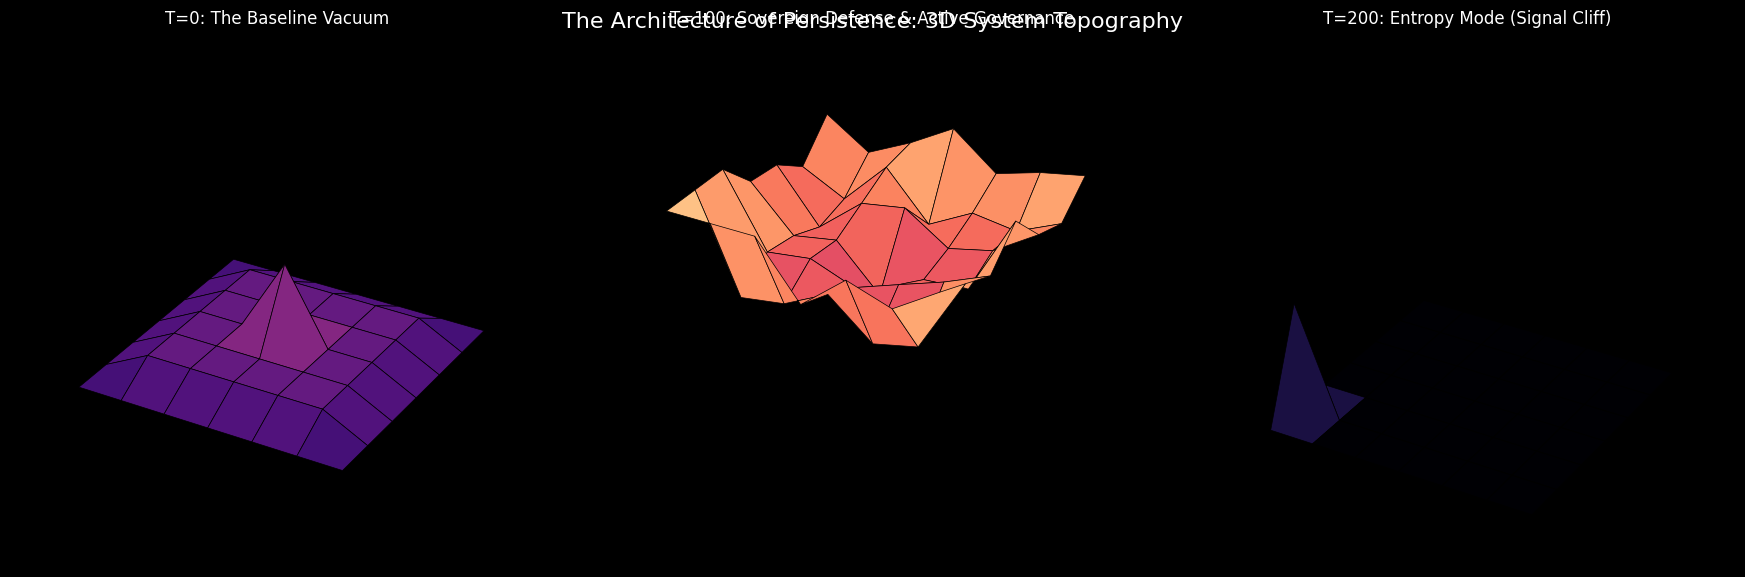

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =====================================================================
# MODULAR SIMULATION ENGINE
# =====================================================================

class SovereignNode:
    def __init__(self, role, phi, c, alpha):
        self.role = role
        self.phi = phi
        self.c = c
        self.alpha = alpha
        self.baseline_phi = 12.0 if role != "Brittle" else 8.0

    def process_event(self, threat, network_c, is_entropy_mode):
        barrier = self.phi + self.c + network_c
        leakage = max(0.0, threat - barrier)

        if leakage > 0:
            if is_entropy_mode:
                self.phi = max(0.0, self.phi - (self.alpha * leakage))
            else:
                self.phi = min(40.0, self.phi + (self.alpha * leakage))
        return leakage

    def decay(self):
        # Soften towards baseline
        if self.phi > self.baseline_phi:
            self.phi = max(self.baseline_phi, self.phi - 0.1)
        elif self.phi < self.baseline_phi:
            self.phi = min(self.baseline_phi, self.phi + 0.1)

class OasisSimulation:
    def __init__(self, size=7):
        self.size = size
        self.grid = np.empty((size, size), dtype=object)
        self.history_3d = {}

        # Initialize the Heterogeneous Ecology
        for r in range(size):
            for c in range(size):
                if r == 3 and c == 3:
                    self.grid[r][c] = SovereignNode("Kernel", 25.0, 8.0, 0.2)
                elif r == 0 or r == size-1 or c == 0 or c == size-1:
                    self.grid[r][c] = SovereignNode("Brittle", 8.0, 1.0, 0.8)
                else:
                    self.grid[r][c] = SovereignNode("Standard", 12.0, 3.0, 0.5)

    def get_coupling(self, r, c):
        support = 0.0
        factor = 0.20
        if r > 0: support += self.grid[r-1][c].phi * factor
        if r < self.size-1: support += self.grid[r+1][c].phi * factor
        if c > 0: support += self.grid[r][c-1].phi * factor
        if c < self.size-1: support += self.grid[r][c+1].phi * factor
        return support

    def active_governance(self):
        # The Sovereign Kernel detects weak edges and redistributes its own Phi to save them
        kernel = self.grid[3][3]
        if kernel.phi > 15.0: # If the core has surplus strength
            for r in range(self.size):
                for c in range(self.size):
                    node = self.grid[r][c]
                    if node.role == "Brittle" and node.phi < 5.0:
                        # Transfer 1.0 Phi from Kernel to Brittle Node
                        kernel.phi -= 1.0
                        node.phi += 1.0

    def capture_state(self):
        state = np.zeros((self.size, self.size))
        for r in range(self.size):
            for c in range(self.size):
                state[r][c] = self.grid[r][c].phi
        return state

    def run(self, steps=200):
        self.history_3d[0] = self.capture_state()

        for t in range(1, steps + 1):
            entropy_mode = True if t > 100 else False

            # Active Governance Phase (The Kernel Projects Power)
            if not entropy_mode:
                self.active_governance()

            # Environmental Threat Phase
            for r in range(self.size):
                for c in range(self.size):
                    threat = np.random.normal(15, 5)
                    if t % 30 == 0: threat += 40.0 # Kinetic Shocks

                    net_c = self.get_coupling(r, c)
                    self.grid[r][c].process_event(threat, net_c, entropy_mode)

            # Decay Phase
            for r in range(self.size):
                for c in range(self.size):
                    self.grid[r][c].decay()

            # Capture specific structural moments for the 3D plot
            if t == 100:
                self.history_3d[100] = self.capture_state()
            elif t == 200:
                self.history_3d[200] = self.capture_state()

# =====================================================================
# PUBLICATION-GRADE 3D TOPOGRAPHY VISUALIZATION
# =====================================================================

print("Initializing Sovereign Lattice...")
sim = OasisSimulation(size=7)
sim.run(steps=200)

# Prepare 3D plotting grid
x = np.arange(7)
y = np.arange(7)
X, Y = np.meshgrid(x, y)

plt.style.use('dark_background')
fig = plt.figure(figsize=(18, 6))
fig.suptitle("The Architecture of Persistence: 3D System Topography", fontsize=16, color='white', y=0.95)

# Panel 1: Baseline (t=0)
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(X, Y, sim.history_3d[0], cmap='magma', vmin=0, vmax=40, edgecolor='black', linewidth=0.5)
ax1.set_title("T=0: The Baseline Vacuum", fontsize=12)
ax1.set_zlim(0, 40)
ax1.set_zlabel("Work Function (Phi)")
ax1.axis('off')

# Panel 2: Peak Fortification (t=100)
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(X, Y, sim.history_3d[100], cmap='magma', vmin=0, vmax=40, edgecolor='black', linewidth=0.5)
ax2.set_title("T=100: Sovereign Defense & Active Governance", fontsize=12)
ax2.set_zlim(0, 40)
ax2.axis('off')

# Panel 3: Post-Bifurcation Collapse (t=200)
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(X, Y, sim.history_3d[200], cmap='magma', vmin=0, vmax=40, edgecolor='black', linewidth=0.5)
ax3.set_title("T=200: Entropy Mode (Signal Cliff)", fontsize=12)
ax3.set_zlim(0, 40)
ax3.axis('off')

plt.tight_layout()
plt.show()

Initializing Unified Oasis Engine...
Running Bifurcation Experiment...
Rendering Figures...


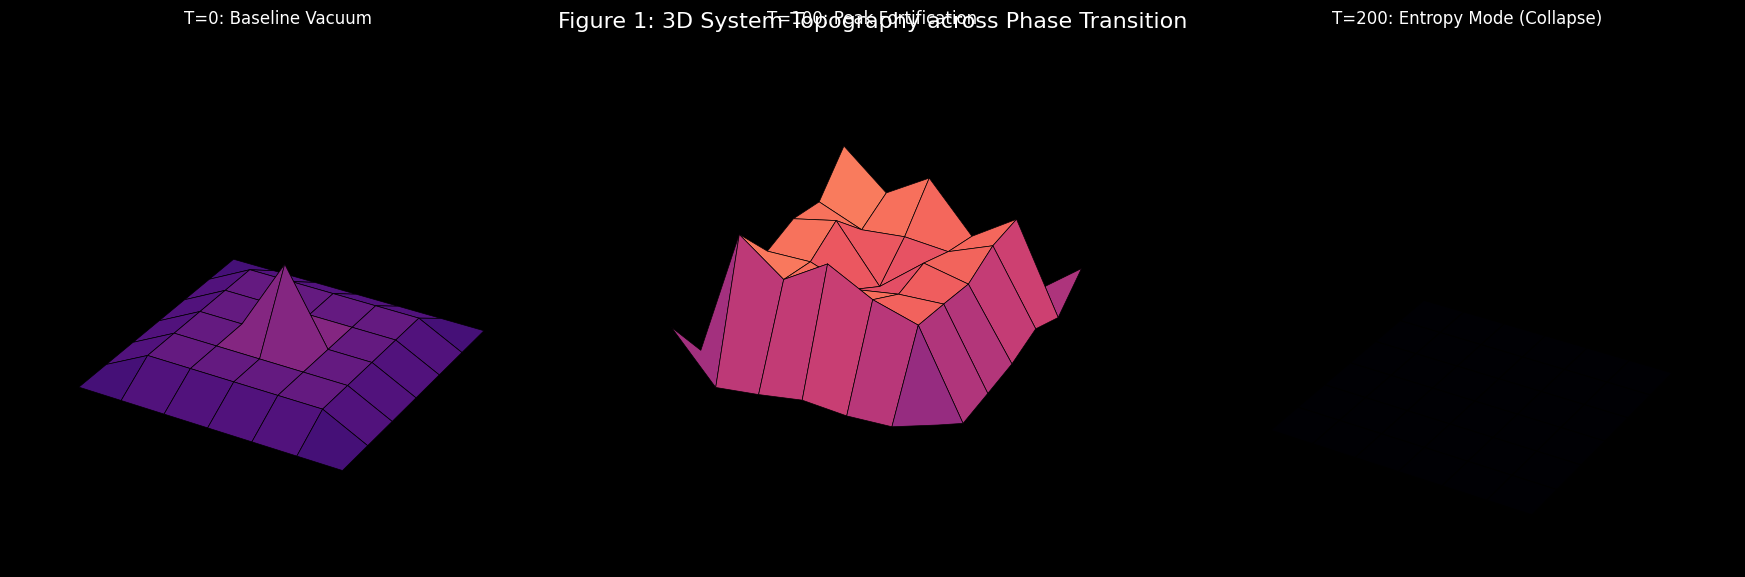

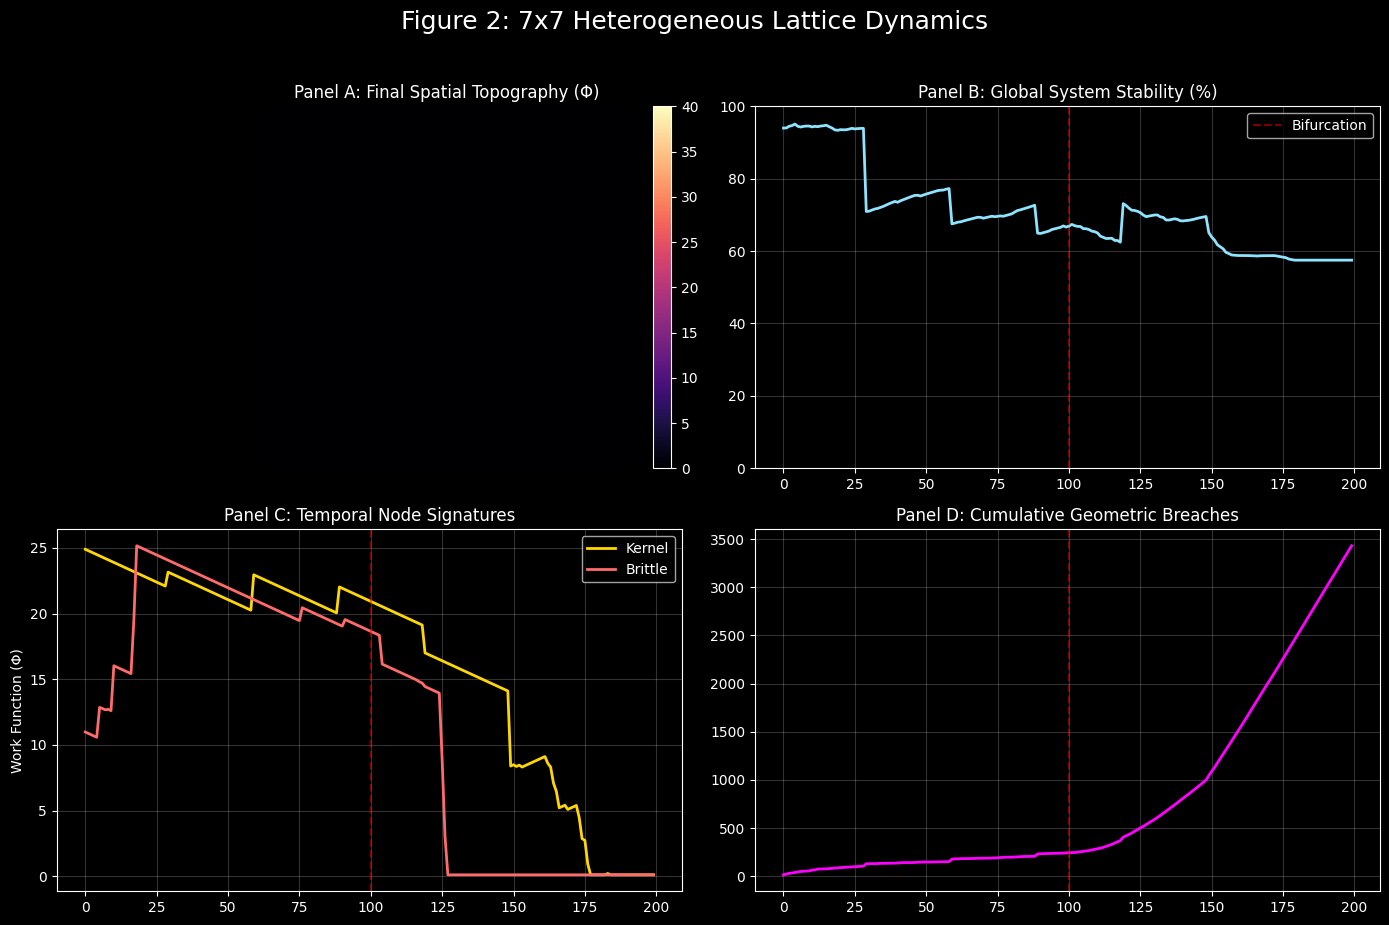

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# CORE PHYSICS: OASIS NODE
# ============================================================

class OasisNode:
    """
    Fundamental unit of the Oasis Engine.
    Holds Φ, coupling c, response α, and a role label.
    Implements the unified operator: barrier, leakage, defense/entropy update, decay.
    """
    def __init__(
        self,
        role: str,
        phi: float,
        coupling: float,
        alpha: float,
        baseline_phi: float = 12.0,
        min_phi: float = 0.0,
        max_phi: float = 40.0,
    ):
        self.role = role
        self.phi = phi
        self.c = coupling
        self.alpha = alpha
        self.baseline_phi = baseline_phi
        self.min_phi = min_phi
        self.max_phi = max_phi
        self.breach_count = 0

    def process_event(self, threat: float, network_c: float, is_entropy_mode: bool) -> float:
        """
        Unified operator:
        - Compute barrier = φ + c + network_c
        - Compute leakage = max(0, threat - barrier)
        - Defense mode: φ += α * leakage
        - Entropy mode: φ -= α * leakage
        """
        barrier = self.phi + self.c + network_c
        leakage = max(0.0, threat - barrier)

        if leakage > 0.0:
            self.breach_count += 1
            if is_entropy_mode:
                self.phi = max(self.min_phi, self.phi - (self.alpha * leakage))
            else:
                self.phi = min(self.max_phi, self.phi + (self.alpha * leakage))

        return leakage

    def decay(self, decay_rate: float):
        """
        Temporal decay toward baseline attractor.
        Hardened nodes decay down; fractured nodes heal up.
        """
        if self.phi > self.baseline_phi:
            self.phi = max(self.baseline_phi, self.phi - decay_rate)
        elif self.phi < self.baseline_phi:
            self.phi = min(self.baseline_phi, self.phi + decay_rate)


# ============================================================
# TOPOLOGY ABSTRACTION
# ============================================================

class BaseTopology:
    def __init__(self, min_phi=0.0, max_phi=40.0, baseline_phi=12.0, neighbor_coupling_factor=0.20):
        self.min_phi = min_phi
        self.max_phi = max_phi
        self.baseline_phi = baseline_phi
        self.k = neighbor_coupling_factor
        self.nodes = None

    @property
    def shape(self):
        return self.nodes.shape

    def get_node(self, r, c) -> OasisNode:
        return self.nodes[r, c]

    def get_network_coupling(self, r, c) -> float:
        support = 0.0
        rows, cols = self.shape
        if r > 0: support += self.nodes[r - 1, c].phi * self.k
        if r < rows - 1: support += self.nodes[r + 1, c].phi * self.k
        if c > 0: support += self.nodes[r, c - 1].phi * self.k
        if c < cols - 1: support += self.nodes[r, c + 1].phi * self.k
        return support

    def phi_field(self) -> np.ndarray:
        rows, cols = self.shape
        phi = np.zeros((rows, cols))
        for r in range(rows):
            for c in range(cols):
                phi[r, c] = self.nodes[r, c].phi
        return phi

    def calculate_stability(self) -> float:
        total_variance = 0.0
        max_dev = max(self.max_phi - self.baseline_phi, self.baseline_phi - self.min_phi)
        rows, cols = self.shape
        max_variance = (rows * cols) * max_dev

        for r in range(rows):
            for c in range(cols):
                total_variance += abs(self.nodes[r, c].phi - self.baseline_phi)

        disturbance = total_variance / max_variance if max_variance > 0 else 0
        return round((1.0 - disturbance) * 100.0, 2)


class HeterogeneousTopology(BaseTopology):
    """
    7x7 heterogeneous lattice: Kernel at center, Brittle frontier at edges.
    """
    def __init__(self, size=7, anchor_phi=25.0, brittle_phi=8.0, standard_phi=12.0,
                 anchor_c=8.0, brittle_c=1.0, standard_c=3.0,
                 anchor_alpha=0.2, brittle_alpha=0.8, standard_alpha=0.5,
                 baseline_phi=12.0, neighbor_coupling_factor=0.20, min_phi=0.0, max_phi=40.0):

        super().__init__(min_phi, max_phi, baseline_phi, neighbor_coupling_factor)
        self.size = size
        self.nodes = np.empty((size, size), dtype=object)
        center = size // 2

        for r in range(size):
            for c in range(size):
                if r == center and c == center:
                    self.nodes[r, c] = OasisNode("Kernel", anchor_phi, anchor_c, anchor_alpha, baseline_phi, min_phi, max_phi)
                elif r == 0 or r == size - 1 or c == 0 or c == size - 1:
                    self.nodes[r, c] = OasisNode("Brittle", brittle_phi, brittle_c, brittle_alpha, 8.0, min_phi, max_phi) # Lower baseline for Brittle
                else:
                    self.nodes[r, c] = OasisNode("Standard", standard_phi, standard_c, standard_alpha, baseline_phi, min_phi, max_phi)

# ============================================================
# THE ENGINE (Temporal & Event Execution)
# ============================================================

class OasisEngine:
    def __init__(self, topology: BaseTopology, active_governance=True, decay_rate=0.1):
        self.topology = topology
        self.active_governance = active_governance
        self.decay_rate = decay_rate

    def execute_governance(self):
        rows, cols = self.topology.shape
        kernel = None

        for r in range(rows):
            for c in range(cols):
                if self.topology.nodes[r, c].role == "Kernel":
                    kernel = self.topology.nodes[r, c]
                    break

        if kernel and kernel.phi > 15.0:
            for r in range(rows):
                for c in range(cols):
                    node = self.topology.nodes[r, c]
                    if node.role == "Brittle" and node.phi < 5.0:
                        kernel.phi -= 1.0
                        node.phi += 1.0

    def run_bifurcation(self, t_switch=100, t_max=200):
        history = {
            'stability': [],
            'center_phi': [],
            'edge_phi': [],
            'breaches': [],
            'snapshots': {},
            't_switch': t_switch
        }

        rows, cols = self.topology.shape
        global_breaches = 0

        history['snapshots'][0] = self.topology.phi_field()

        for t in range(1, t_max + 1):
            entropy_mode = True if t > t_switch else False

            if self.active_governance and not entropy_mode:
                self.execute_governance()

            for r in range(rows):
                for c in range(cols):
                    threat = np.random.normal(15, 5)
                    # Periodic Kinetic Shock
                    if t % 30 == 0 and 1 <= r <= rows-2 and 1 <= c <= cols-2:
                        threat += 40.0

                    net_c = self.topology.get_network_coupling(r, c)
                    leakage = self.topology.nodes[r, c].process_event(threat, net_c, entropy_mode)
                    if leakage > 0:
                        global_breaches += 1

            for r in range(rows):
                for c in range(cols):
                    self.topology.nodes[r, c].decay(self.decay_rate)

            # Log Data
            history['stability'].append(self.topology.calculate_stability())
            history['center_phi'].append(self.topology.nodes[rows//2, cols//2].phi)
            history['edge_phi'].append(self.topology.nodes[0, 0].phi)
            history['breaches'].append(global_breaches)

            if t == t_switch:
                history['snapshots'][t_switch] = self.topology.phi_field()
            elif t == t_max:
                history['snapshots'][t_max] = self.topology.phi_field()

        return history

# ============================================================
# THE VISUALIZER (Publication Outputs)
# ============================================================

class OasisVisualizer:
    def __init__(self, history):
        self.h = history
        plt.style.use('dark_background')

    def plot_figure_1_topography(self):
        fig = plt.figure(figsize=(18, 6))
        fig.suptitle("Figure 1: 3D System Topography across Phase Transition", fontsize=16, color='white', y=0.95)

        t_switch = self.h['t_switch']
        t_max = max(self.h['snapshots'].keys())

        size = self.h['snapshots'][0].shape[0]
        X, Y = np.meshgrid(np.arange(size), np.arange(size))

        titles = ["T=0: Baseline Vacuum", f"T={t_switch}: Peak Fortification", f"T={t_max}: Entropy Mode (Collapse)"]
        keys = [0, t_switch, t_max]

        for i in range(3):
            ax = fig.add_subplot(1, 3, i+1, projection='3d')
            ax.plot_surface(X, Y, self.h['snapshots'][keys[i]], cmap='magma', vmin=0, vmax=40, edgecolor='black', linewidth=0.5)
            ax.set_title(titles[i], fontsize=12)
            ax.set_zlim(0, 40)
            if i == 0: ax.set_zlabel("Work Function (Φ)")
            ax.axis('off')

        plt.tight_layout()
        plt.show()

    def plot_figure_2_signatures(self):
        fig, axs = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle("Figure 2: 7x7 Heterogeneous Lattice Dynamics", fontsize=18, color='white', y=0.95)

        t_switch = self.h['t_switch']
        time_steps = len(self.h['stability'])

        # Panel A
        t_max = max(self.h['snapshots'].keys())
        im = axs[0, 0].imshow(self.h['snapshots'][t_max], cmap='magma', vmin=0, vmax=40)
        axs[0, 0].set_title("Panel A: Final Spatial Topography (Φ)", fontsize=12)
        axs[0, 0].axis('off')
        fig.colorbar(im, ax=axs[0, 0], fraction=0.046, pad=0.04)

        # Panel B
        axs[0, 1].plot(range(time_steps), self.h['stability'], color='#8EE3FF', linewidth=2)
        axs[0, 1].axvline(x=t_switch, color='red', linestyle='--', alpha=0.5, label="Bifurcation")
        axs[0, 1].set_title("Panel B: Global System Stability (%)", fontsize=12)
        axs[0, 1].set_ylim(0, 100)
        axs[0, 1].grid(True, alpha=0.2)
        axs[0, 1].legend()

        # Panel C
        axs[1, 0].plot(range(time_steps), self.h['center_phi'], color='#FFD700', linewidth=2, label="Kernel")
        axs[1, 0].plot(range(time_steps), self.h['edge_phi'], color='#FF6B6B', linewidth=2, label="Brittle")
        axs[1, 0].axvline(x=t_switch, color='red', linestyle='--', alpha=0.5)
        axs[1, 0].set_title("Panel C: Temporal Node Signatures", fontsize=12)
        axs[1, 0].set_ylabel("Work Function (Φ)")
        axs[1, 0].grid(True, alpha=0.2)
        axs[1, 0].legend()

        # Panel D
        axs[1, 1].plot(range(time_steps), self.h['breaches'], color='magenta', linewidth=2)
        axs[1, 1].axvline(x=t_switch, color='red', linestyle='--', alpha=0.5)
        axs[1, 1].set_title("Panel D: Cumulative Geometric Breaches", fontsize=12)
        axs[1, 1].grid(True, alpha=0.2)

        plt.tight_layout(rect=[0, 0.03, 1, 0.93])
        plt.show()

# ============================================================
# API EXECUTION
# ============================================================
if __name__ == "__main__":
    print("Initializing Unified Oasis Engine...")

    # 1. Instantiate Topology
    topology = HeterogeneousTopology(size=7)

    # 2. Bind to Engine
    engine = OasisEngine(topology=topology, active_governance=True)

    # 3. Run Phase Transition
    print("Running Bifurcation Experiment...")
    history = engine.run_bifurcation(t_switch=100, t_max=200)

    # 4. Generate Manuscript Figures
    print("Rendering Figures...")
    visualizer = OasisVisualizer(history)
    visualizer.plot_figure_1_topography()
    visualizer.plot_figure_2_signatures()

Initializing Unified Oasis Engine...
Running Phase Transition Experiment...
Generating Manuscript Figures...


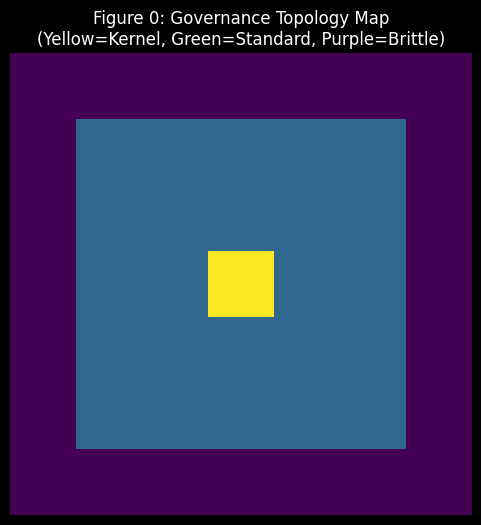

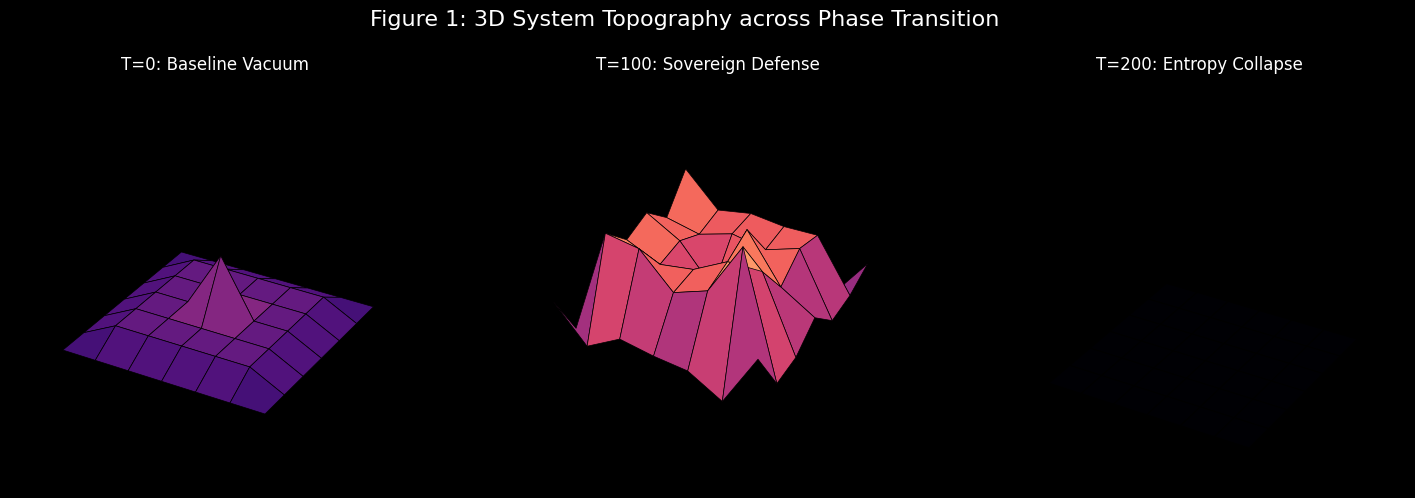

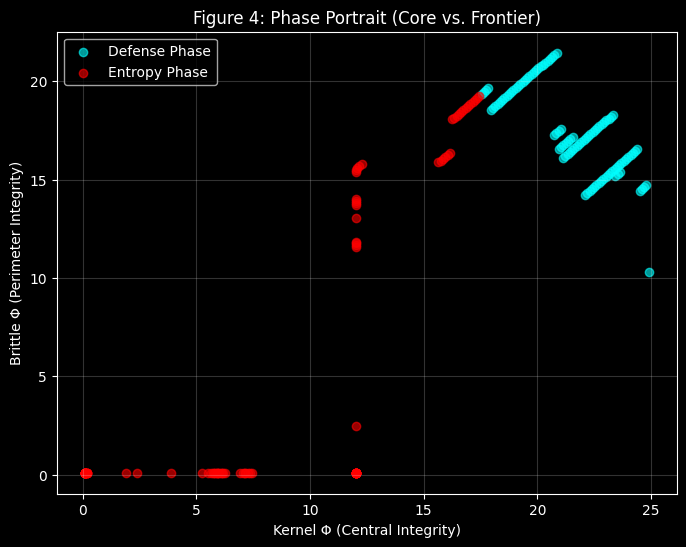

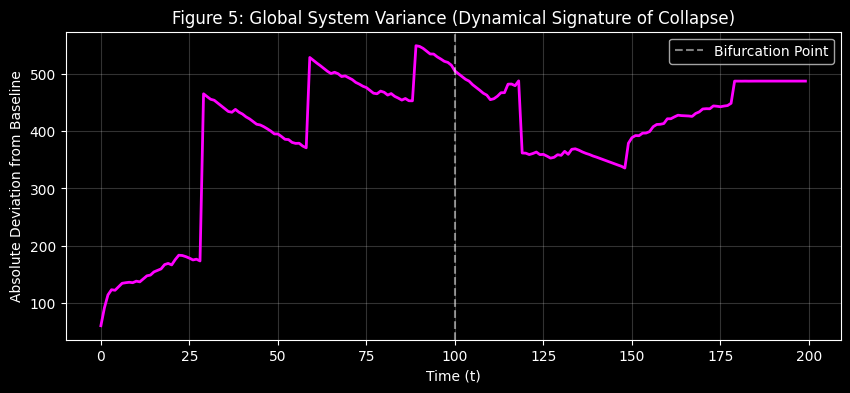

Export complete. Ready for manuscript insertion.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pickle
import os

# ============================================================
# 1. CORE PHYSICS: THE UNIFIED OPERATOR
# ============================================================

class OasisNode:
    """
    The fundamental quantum of the Oasis Engine.
    Topology-invariant. Executes the core thermodynamic logic.
    """
    def __init__(self, role: str, phi: float, coupling: float, alpha: float,
                 baseline_phi: float = 12.0, min_phi: float = 0.0, max_phi: float = 40.0):
        self.role = role
        self.phi = phi
        self.c = coupling
        self.alpha = alpha
        self.baseline_phi = baseline_phi
        self.min_phi = min_phi
        self.max_phi = max_phi
        self.breach_count = 0

    def process_event(self, threat: float, network_c: float, is_entropy_mode: bool) -> float:
        barrier = self.phi + self.c + network_c
        leakage = max(0.0, threat - barrier)

        if leakage > 0.0:
            self.breach_count += 1
            if is_entropy_mode:
                self.phi = max(self.min_phi, self.phi - (self.alpha * leakage))
            else:
                self.phi = min(self.max_phi, self.phi + (self.alpha * leakage))
        return leakage

    def decay(self, decay_rate: float):
        if self.phi > self.baseline_phi:
            self.phi = max(self.baseline_phi, self.phi - decay_rate)
        elif self.phi < self.baseline_phi:
            self.phi = min(self.baseline_phi, self.phi + decay_rate)

# ============================================================
# 2. TOPOLOGY ABSTRACTION & FACTORY
# ============================================================

class BaseTopology:
    def __init__(self, neighbor_coupling_factor=0.20):
        self.k = neighbor_coupling_factor
        self.nodes = None

    @property
    def shape(self):
        return self.nodes.shape

    def get_network_coupling(self, r, c) -> float:
        support = 0.0
        rows, cols = self.shape
        if r > 0: support += self.nodes[r - 1, c].phi * self.k
        if r < rows - 1: support += self.nodes[r + 1, c].phi * self.k
        if c > 0: support += self.nodes[r, c - 1].phi * self.k
        if c < cols - 1: support += self.nodes[r, c + 1].phi * self.k
        return support

    def phi_field(self) -> np.ndarray:
        rows, cols = self.shape
        return np.array([[self.nodes[r, c].phi for c in range(cols)] for r in range(rows)])

    def roles_field(self) -> np.ndarray:
        rows, cols = self.shape
        # Map roles to integers for visualization
        role_map = {"Kernel": 3, "Repeater": 2, "Standard": 1, "Brittle": 0}
        return np.array([[role_map.get(self.nodes[r, c].role, 1) for c in range(cols)] for r in range(rows)])

    def calculate_variance(self) -> float:
        rows, cols = self.shape
        total_variance = sum(abs(self.nodes[r, c].phi - self.nodes[r, c].baseline_phi) for r in range(rows) for c in range(cols))
        return total_variance

class LineTopology(BaseTopology):
    """1D Geometry (The physical Cojo-Jalama Repeater Chain)"""
    def __init__(self, size=8, baseline=12.0):
        super().__init__()
        self.nodes = np.empty((1, size), dtype=object)
        for c in range(size):
            self.nodes[0, c] = OasisNode("Repeater", baseline, 3.0, 0.5, baseline)

class GridTopology(BaseTopology):
    """2D Homogeneous Geometry (The 3x3 Pedagogical Matrix)"""
    def __init__(self, size=3, baseline=12.0):
        super().__init__()
        self.nodes = np.empty((size, size), dtype=object)
        for r in range(size):
            for c in range(size):
                self.nodes[r, c] = OasisNode("Standard", baseline, 3.0, 0.5, baseline)

class HeterogeneousTopology(BaseTopology):
    """The 7x7 Governance Ecology"""
    def __init__(self, size=7):
        super().__init__()
        self.nodes = np.empty((size, size), dtype=object)
        center = size // 2
        for r in range(size):
            for c in range(size):
                if r == center and c == center:
                    self.nodes[r, c] = OasisNode("Kernel", 25.0, 8.0, 0.2, 12.0)
                elif r == 0 or r == size - 1 or c == 0 or c == size - 1:
                    self.nodes[r, c] = OasisNode("Brittle", 8.0, 1.0, 0.8, 8.0)
                else:
                    self.nodes[r, c] = OasisNode("Standard", 12.0, 3.0, 0.5, 12.0)

class TopologyFactory:
    @staticmethod
    def create(topology_type="heterogeneous_7x7", size=None):
        if topology_type == "line_1d": return LineTopology(size=size or 8)
        if topology_type == "grid_3x3": return GridTopology(size=size or 3)
        if topology_type == "heterogeneous_7x7": return HeterogeneousTopology(size=size or 7)
        raise ValueError("Unknown topology type.")

# ============================================================
# 3. THE ENGINE
# ============================================================

class OasisEngine:
    def __init__(self, topology: BaseTopology, active_governance=True, decay_rate=0.1):
        self.topology = topology
        self.active_governance = active_governance
        self.decay_rate = decay_rate

    def execute_governance(self):
        rows, cols = self.topology.shape
        kernel = None
        for r in range(rows):
            for c in range(cols):
                if self.topology.nodes[r, c].role == "Kernel":
                    kernel = self.topology.nodes[r, c]
                    break

        # The Shielding Protocol
        if kernel and kernel.phi > 15.0:
            for r in range(rows):
                for c in range(cols):
                    node = self.topology.nodes[r, c]
                    if node.role == "Brittle" and node.phi < 5.0:
                        kernel.phi -= 1.0
                        node.phi += 1.0

    def run_bifurcation(self, t_switch=100, t_max=200):
        history = {
            'variance': [],
            'center_phi': [],
            'edge_phi': [],
            'breaches': [],
            'snapshots': {},
            't_switch': t_switch,
            'roles': self.topology.roles_field()
        }

        rows, cols = self.topology.shape
        global_breaches = 0
        history['snapshots'][0] = self.topology.phi_field()

        for t in range(1, t_max + 1):
            entropy_mode = (t > t_switch)

            if self.active_governance and not entropy_mode:
                self.execute_governance()

            for r in range(rows):
                for c in range(cols):
                    threat = np.random.normal(15, 5)
                    if t % 30 == 0 and 1 <= r <= rows-2 and 1 <= c <= cols-2:
                        threat += 40.0

                    net_c = self.topology.get_network_coupling(r, c)
                    if self.topology.nodes[r, c].process_event(threat, net_c, entropy_mode) > 0:
                        global_breaches += 1

            for r in range(rows):
                for c in range(cols):
                    self.topology.nodes[r, c].decay(self.decay_rate)

            # Telemetry Logging
            history['variance'].append(self.topology.calculate_variance())
            history['center_phi'].append(self.topology.nodes[rows//2, cols//2].phi)
            history['edge_phi'].append(self.topology.nodes[0, 0].phi)
            history['breaches'].append(global_breaches)

            if t == t_switch or t == t_max:
                history['snapshots'][t] = self.topology.phi_field()

        return history

    @staticmethod
    def save_history(history, filename="oasis_run.pkl"):
        with open(filename, 'wb') as f:
            pickle.dump(history, f)

    @staticmethod
    def load_history(filename="oasis_run.pkl"):
        with open(filename, 'rb') as f:
            return pickle.load(f)

# ============================================================
# 4. MANUSCRIPT VISUALIZER
# ============================================================

class OasisVisualizer:
    def __init__(self, history, output_dir="manuscript_figs"):
        self.h = history
        self.out_dir = output_dir
        if not os.path.exists(self.out_dir): os.makedirs(self.out_dir)
        plt.style.use('dark_background')

    def plot_figure_0_topology(self):
        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(self.h['roles'], cmap='viridis')
        ax.set_title("Figure 0: Governance Topology Map\n(Yellow=Kernel, Green=Standard, Purple=Brittle)")
        ax.axis('off')
        plt.savefig(f"{self.out_dir}/Fig0_Topology.png", dpi=300, bbox_inches='tight')
        plt.show()

    def plot_figure_1_topography(self):
        fig = plt.figure(figsize=(18, 6))
        fig.suptitle("Figure 1: 3D System Topography across Phase Transition", fontsize=16, y=0.95)

        t_switch, t_max = self.h['t_switch'], max(self.h['snapshots'].keys())
        size = self.h['snapshots'][0].shape[0]
        X, Y = np.meshgrid(np.arange(size), np.arange(size))

        titles = ["T=0: Baseline Vacuum", f"T={t_switch}: Sovereign Defense", f"T={t_max}: Entropy Collapse"]
        keys = [0, t_switch, t_max]

        for i in range(3):
            ax = fig.add_subplot(1, 3, i+1, projection='3d')
            ax.plot_surface(X, Y, self.h['snapshots'][keys[i]], cmap='magma', vmin=0, vmax=40, edgecolor='black', linewidth=0.5)
            ax.set_title(titles[i], fontsize=12)
            ax.set_zlim(0, 40)
            if i == 0: ax.set_zlabel("Work Function (Φ)")
            ax.axis('off')

        plt.savefig(f"{self.out_dir}/Fig1_Topography.png", dpi=300, bbox_inches='tight')
        plt.show()

    def plot_figure_4_phase_portrait(self):
        fig, ax = plt.subplots(figsize=(8, 6))
        t_switch = self.h['t_switch']

        # Defense Trajectory
        ax.scatter(self.h['center_phi'][:t_switch], self.h['edge_phi'][:t_switch], c='cyan', alpha=0.6, label='Defense Phase')
        # Entropy Trajectory
        ax.scatter(self.h['center_phi'][t_switch:], self.h['edge_phi'][t_switch:], c='red', alpha=0.6, label='Entropy Phase')

        ax.set_title("Figure 4: Phase Portrait (Core vs. Frontier)")
        ax.set_xlabel("Kernel Φ (Central Integrity)")
        ax.set_ylabel("Brittle Φ (Perimeter Integrity)")
        ax.grid(True, alpha=0.2)
        ax.legend()
        plt.savefig(f"{self.out_dir}/Fig4_PhasePortrait.png", dpi=300, bbox_inches='tight')
        plt.show()

    def plot_figure_5_variance(self):
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(self.h['variance'], color='magenta', linewidth=2)
        ax.axvline(x=self.h['t_switch'], color='white', linestyle='--', alpha=0.5, label="Bifurcation Point")

        ax.set_title("Figure 5: Global System Variance (Dynamical Signature of Collapse)")
        ax.set_ylabel("Absolute Deviation from Baseline")
        ax.set_xlabel("Time (t)")
        ax.grid(True, alpha=0.2)
        ax.legend()
        plt.savefig(f"{self.out_dir}/Fig5_Variance.png", dpi=300, bbox_inches='tight')
        plt.show()

# ============================================================
# 5. EXECUTION & EXPORT
# ============================================================
if __name__ == "__main__":
    print("Initializing Unified Oasis Engine...")
    topology = TopologyFactory.create("heterogeneous_7x7")
    engine = OasisEngine(topology=topology, active_governance=True)

    print("Running Phase Transition Experiment...")
    history = engine.run_bifurcation(t_switch=100, t_max=200)
    OasisEngine.save_history(history)

    print("Generating Manuscript Figures...")
    viz = OasisVisualizer(history)
    viz.plot_figure_0_topology()
    viz.plot_figure_1_topography()
    viz.plot_figure_4_phase_portrait()
    viz.plot_figure_5_variance()
    print("Export complete. Ready for manuscript insertion.")